### Setup | Confirm the Kaggle runtime

**Purpose:** Record the Python version and check that the EEG and machine-learning packages are available on Kaggle. **Expected output:** One availability line per package. This is an environment check; it does not process EEG data or train a model.


In [2]:
# EEG-CNN Approximate-MAC research: Phase A bootstrap
# Step 1 — record the runtime and confirm the EEG tooling is available.
import sys, importlib.util
print('Python:', sys.version)
for package in ('mne', 'moabb', 'torch', 'numpy', 'sklearn'):
    print(f'{package}:', bool(importlib.util.find_spec(package)))

# Kaggle normally includes MNE and PyTorch. If MNE is missing, install it in
# this session with: %pip install mne moabb

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
mne: True
moabb: False
torch: True
numpy: True
sklearn: True


### Phase A, pilot | Inspect EEGMMIDB source recordings

**Purpose:** Fetch four EDF runs for subject 1 and inspect channels, sampling frequency, recording duration, and event annotations. **Expected output:** Four file names and representative metadata. This small source check establishes how the later full-cohort loader should interpret the data.


In [3]:
# Step 2 — fetch the prompt-aligned single-subject smoke-test set.
# EEGMMIDB runs 4/8/12 are imagined left-vs-right fist tasks; run 1 is eyes-open baseline.
# This is a small protocol check before any cohort-wide download.
from pathlib import Path
import mne

DATA_ROOT = Path('/kaggle/working/eeg-axmac/data/raw')
DATA_ROOT.mkdir(parents=True, exist_ok=True)
files = mne.datasets.eegbci.load_data(subjects=[1], runs=[1, 4, 8, 12], path=str(DATA_ROOT), update_path=True)
print(f'Fetched {len(files)} EDF files:')
for file in files:
    print(Path(file).name, Path(file).stat().st_size, 'bytes')

# Inspect baseline run 1 and one left/right imagery run (run 4).
raw_baseline = mne.io.read_raw_edf(files[0], preload=False, verbose='ERROR')
raw_imagery = mne.io.read_raw_edf(files[1], preload=False, verbose='ERROR')
for label, raw in [('eyes-open baseline', raw_baseline), ('left/right imagery', raw_imagery)]:
    print(label, '| channels:', len(raw.ch_names), '| sfreq:', raw.info['sfreq'], '| duration:', round(raw.n_times / raw.info['sfreq'], 1), 's')
    print('annotations:', list(zip(raw.annotations.description, raw.annotations.onset))[:8])

Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Fetched 4 EDF files:
S001R01.edf 1275936 bytes
S001R04.edf 2596896 bytes
S001R08.edf 2596896 bytes
S001R12.edf 2596896 bytes
eyes-open baseline | channels: 64 | sfreq: 160.0 | duration: 61.0 s
annotations: [(np.str_('T0'), np.float64(0.0))]
left/right imagery | channels: 64 | sfreq: 160.0 | duration: 125.0 s
annotations: [(np.str_('T0'), np.float64(0.0)), (np.str_('T2'), np.float64(4.2)), (np.str_('T0'), np.float64(8.3)), (np.str_('T1'), np.float64(12.5)), (np.str_('T0'), np.float64(16.6)), (np.str_('T1'), np.float64(20.8)), (np.str_('T0'), np.float64(24.9)), (np.str_('T2'), np.float64(29.1))]


### Phase A, pilot | Check four-class EEGMMIDB preprocessing

**Purpose:** Filter one subject at 0.5–40 Hz; create 3-second left-hand, right-hand, eyes-open-rest, and feet-imagery windows; split trials; and fit normalization on training windows only. **Expected output:** A saved pilot cache, class counts, and a checked `(N, 64, 1, 480)` tensor. This is a preprocessing smoke test, not a subject-independent result.


In [4]:
# Step 3 — 0.5–40 Hz filter, 3 s epochs, train-only normalization, and cache.
from pathlib import Path
import numpy as np, mne
from sklearn.model_selection import train_test_split
SEED=42
EDF_DIR=DATA_ROOT/'MNE-eegbci-data/files/eegmmidb/1.0.0/S001'
def read_run(run):
    raw=mne.io.read_raw_edf(EDF_DIR/f'S001R{run:02d}.edf',preload=True,verbose='ERROR')
    raw.pick('eeg').filter(0.5,40.0,verbose='ERROR')
    return raw
xs=[]; ys=[]
# Prompt classes: 0=L, 1=R, 2=eyes-open rest, 3=feet imagery.
for run in (4,8,12):
    raw=read_run(run); events,_=mne.events_from_annotations(raw,event_id={'T1':1,'T2':2},verbose='ERROR')
    ep=mne.Epochs(raw,events,event_id={'T1':1,'T2':2},tmin=0,tmax=479/160,baseline=None,preload=True,picks='eeg',verbose='ERROR')
    x=ep.get_data()[:,:,:480].astype(np.float32); y=np.where(ep.events[:,-1]==1,0,1).astype(np.int64)
    xs.append(x); ys.append(y); print('L/R run',run,x.shape,np.bincount(y,minlength=2))
for run in (6,10,14):
    raw=read_run(run); events,_=mne.events_from_annotations(raw,event_id={'T2':2},verbose='ERROR')
    ep=mne.Epochs(raw,events,event_id={'T2':2},tmin=0,tmax=479/160,baseline=None,preload=True,picks='eeg',verbose='ERROR')
    x=ep.get_data()[:,:,:480].astype(np.float32); xs.append(x); ys.append(np.full(len(x),3,dtype=np.int64)); print('feet run',run,x.shape)
base=read_run(1).get_data(picks='eeg')[:,:60*160]
rest=base[:,:base.shape[1]//480*480].reshape(64,-1,480).transpose(1,0,2).astype(np.float32)
xs.append(rest); ys.append(np.full(len(rest),2,dtype=np.int64))
X=np.concatenate(xs)[:,:,None,:]; y=np.concatenate(ys); print('all',X.shape,'counts L/R/rest/feet',np.bincount(y,minlength=4))
i=np.arange(len(y)); tr,va=train_test_split(i,test_size=.2,random_state=SEED,stratify=y)
mu=X[tr].mean(axis=(0,3),keepdims=True); sd=X[tr].std(axis=(0,3),keepdims=True).clip(min=1e-6); X=((X-mu)/sd).astype(np.float32)
out=Path('/kaggle/working/eeg-axmac/data/processed/eegmmidb_subject01_smoke.npz'); out.parent.mkdir(parents=True,exist_ok=True)
np.savez_compressed(out,X_train=X[tr],y_train=y[tr],X_val=X[va],y_val=y[va],mean=mu,std=sd,seed=SEED)
print('saved',out,'train',X[tr].shape,'val',X[va].shape)
assert X.shape[1:]==(64,1,480) and set(np.unique(y))=={0,1,2,3}

L/R run 4 (15, 64, 480) [8 7]
L/R run 8 (15, 64, 480) [8 7]
L/R run 12 (15, 64, 480) [7 8]
feet run 6 (8, 64, 480)
feet run 10 (8, 64, 480)
feet run 14 (8, 64, 480)
all (89, 64, 1, 480) counts L/R/rest/feet [23 22 20 24]
saved /kaggle/working/eeg-axmac/data/processed/eegmmidb_subject01_smoke.npz train (71, 64, 1, 480) val (18, 64, 1, 480)


### Phase A, pilot | Visualize signal and label diagnostics

**Purpose:** Plot subject-1 class counts, example C3 waveforms, and class-wise power spectra after preprocessing. **Expected output:** A 300 dpi diagnostic figure. These plots show input characteristics only and must not be cited as cross-validation performance.


Saved paper-ready 300 dpi figure: /kaggle/working/eeg-axmac/results/figures/eegmmidb_preprocessing_smoke.png
NOTE: diagnostic pilot figure, n_subjects=1; not a global-CV result.


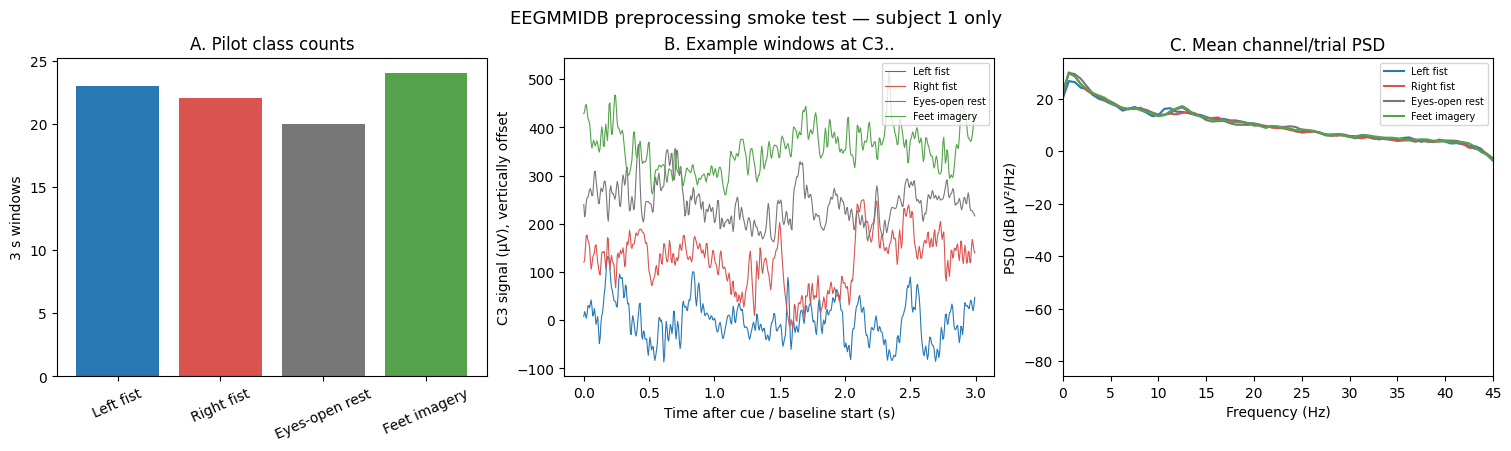

In [5]:
# Step 4 — paper-style preprocessing diagnostics (pilot data only; not CV performance).
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import welch

FIG_DIR=Path('/kaggle/working/eeg-axmac/results/figures'); FIG_DIR.mkdir(parents=True,exist_ok=True)
Xraw=np.concatenate(xs)[:,:,None,:]
class_names=['Left fist','Right fist','Eyes-open rest','Feet imagery']
colors=['#2878B5','#D9534F','#777777','#54A24B']
sfreq=160.0; time=np.arange(480)/sfreq
# Pick C3 when available; otherwise fall back to the first EEG channel.
channel_idx=next((i for i,name in enumerate(raw.ch_names) if name.strip('.').lower()=='c3'),0)
fig,axes=plt.subplots(1,3,figsize=(15,4.4),constrained_layout=True)
counts=np.bincount(y,minlength=4)
axes[0].bar(class_names,counts,color=colors); axes[0].set_ylabel('3 s windows'); axes[0].set_title('A. Pilot class counts'); axes[0].tick_params(axis='x',rotation=24)
for label in range(4):
    ids=np.flatnonzero(y==label); trial=Xraw[ids[0],channel_idx,0]*1e6
    axes[1].plot(time,trial+label*120,color=colors[label],lw=.8,label=class_names[label])
axes[1].set_xlabel('Time after cue / baseline start (s)'); axes[1].set_ylabel('C3 signal (µV), vertically offset'); axes[1].set_title(f'B. Example windows at {raw.ch_names[channel_idx]}'); axes[1].legend(fontsize=7,loc='upper right')
for label in range(4):
    signal=Xraw[y==label,:,0,:]
    f,p=welch(signal,fs=sfreq,nperseg=256,axis=-1)
    psd=p.mean(axis=(0,1))*1e12
    axes[2].plot(f,10*np.log10(psd+1e-20),color=colors[label],label=class_names[label])
axes[2].set_xlim(0,45); axes[2].set_xlabel('Frequency (Hz)'); axes[2].set_ylabel('PSD (dB µV²/Hz)'); axes[2].set_title('C. Mean channel/trial PSD'); axes[2].legend(fontsize=7)
fig.suptitle('EEGMMIDB preprocessing smoke test — subject 1 only',fontsize=13)
fig.savefig(FIG_DIR/'eegmmidb_preprocessing_smoke.png',dpi=300,bbox_inches='tight')
print('Saved paper-ready 300 dpi figure:',FIG_DIR/'eegmmidb_preprocessing_smoke.png')
print('NOTE: diagnostic pilot figure, n_subjects=1; not a global-CV result.')
plt.show()

### Phase B, pilot | Smoke-test EEGNet-8,2

**Purpose:** Instantiate EEGNet-8,2, check tensor output and parameter count, and train briefly on subject-1 windows. **Expected output:** Five training epochs, pilot accuracy and macro-F1, learning curves, and a pilot confusion matrix. The within-subject trial split checks the code path; it is not the Phase B headline accuracy.


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv2d(


EEGNet output shape: (2, 4) parameters: 3092
epoch 1/5 | train loss 1.460 acc 0.183 | val loss 1.383 acc 0.278
epoch 2/5 | train loss 1.373 acc 0.239 | val loss 1.370 acc 0.389
epoch 3/5 | train loss 1.332 acc 0.324 | val loss 1.347 acc 0.500
epoch 4/5 | train loss 1.292 acc 0.423 | val loss 1.320 acc 0.556
epoch 5/5 | train loss 1.262 acc 0.535 | val loss 1.289 acc 0.500
PILOT ONLY — subject 1 held-out trials: ACC=0.500, macro-F1=0.462; n_test=18; chance=0.25
Saved: /kaggle/working/eeg-axmac/results/figures/eegnet_subject01_pilot.png


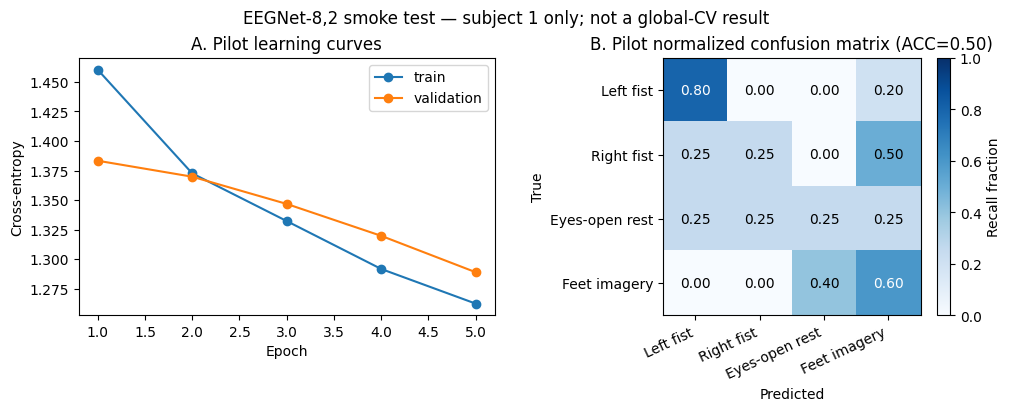

In [6]:
# Step 5 — EEGNet-8,2 architecture check and short single-subject training smoke test.
# Smoke accuracy is a code-path check only; it is not comparable to published global CV.
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
torch.manual_seed(SEED); np.random.seed(SEED); torch.set_num_threads(2)
class EEGNet(nn.Module):
    def __init__(self,n_channels=64,n_samples=480,n_classes=4):
        super().__init__(); f1=8; d=2; f2=16
        self.temporal=nn.Conv2d(1,f1,(1,64),padding='same',bias=False)
        self.bn1=nn.BatchNorm2d(f1)
        self.spatial=nn.Conv2d(f1,f1*d,(n_channels,1),groups=f1,bias=False)
        self.bn2=nn.BatchNorm2d(f1*d); self.elu1=nn.ELU(); self.pool1=nn.AvgPool2d((1,4)); self.drop1=nn.Dropout(.5)
        self.sep_dw=nn.Conv2d(f1*d,f1*d,(1,16),padding='same',groups=f1*d,bias=False)
        self.sep_pw=nn.Conv2d(f1*d,f2,1,bias=False); self.bn3=nn.BatchNorm2d(f2); self.elu2=nn.ELU(); self.pool2=nn.AvgPool2d((1,8)); self.drop2=nn.Dropout(.5)
        n_features=f2*((n_samples//4)//8); self.classifier=nn.Linear(n_features,n_classes)
    def forward(self,x):
        x=x.transpose(1,2)
        x=self.bn1(self.temporal(x)); x=self.elu1(self.bn2(self.spatial(x)))
        x=self.drop1(self.pool1(x)); x=self.sep_pw(self.sep_dw(x)); x=self.elu2(self.bn3(x))
        x=self.drop2(self.pool2(x)); return self.classifier(x.flatten(1))
data=np.load(out)
Xtr=torch.from_numpy(data['X_train']); ytr=torch.from_numpy(data['y_train']).long()
Xva=torch.from_numpy(data['X_val']); yva=torch.from_numpy(data['y_val']).long()
model=EEGNet(); logits=model(Xtr[:2]); print('EEGNet output shape:',tuple(logits.shape),'parameters:',sum(p.numel() for p in model.parameters()))
assert logits.shape==(2,4)
train_loader=DataLoader(TensorDataset(Xtr,ytr),batch_size=16,shuffle=True)
criterion=nn.CrossEntropyLoss(); optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
history={'train_loss':[],'train_acc':[],'val_loss':[],'val_acc':[]}
for epoch in range(5):
    model.train(); total_loss=0; pred_all=[]; true_all=[]
    for xb,yb in train_loader:
        optimizer.zero_grad(); logits=model(xb); loss=criterion(logits,yb); loss.backward(); optimizer.step()
        total_loss+=loss.item()*len(yb); pred_all.extend(logits.argmax(1).detach().tolist()); true_all.extend(yb.tolist())
    history['train_loss'].append(total_loss/len(ytr)); history['train_acc'].append(accuracy_score(true_all,pred_all))
    model.eval()
    with torch.no_grad(): val_logits=model(Xva); val_loss=criterion(val_logits,yva).item(); val_pred=val_logits.argmax(1).numpy()
    history['val_loss'].append(val_loss); history['val_acc'].append(accuracy_score(yva.numpy(),val_pred))
    print('epoch {}/5 | train loss {:.3f} acc {:.3f} | val loss {:.3f} acc {:.3f}'.format(epoch+1,history['train_loss'][-1],history['train_acc'][-1],val_loss,history['val_acc'][-1]))
pilot_acc=accuracy_score(yva.numpy(),val_pred); pilot_f1=f1_score(yva.numpy(),val_pred,average='macro',zero_division=0)
print('PILOT ONLY — subject 1 held-out trials: ACC={:.3f}, macro-F1={:.3f}; n_test={}; chance=0.25'.format(pilot_acc,pilot_f1,len(yva)))
fig,ax=plt.subplots(1,2,figsize=(10,4),constrained_layout=True); epochs=np.arange(1,6)
ax[0].plot(epochs,history['train_loss'],'o-',label='train'); ax[0].plot(epochs,history['val_loss'],'o-',label='validation'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Cross-entropy'); ax[0].set_title('A. Pilot learning curves'); ax[0].legend()
cm=confusion_matrix(yva.numpy(),val_pred,labels=[0,1,2,3]); cmn=cm/np.maximum(cm.sum(axis=1,keepdims=True),1)
im=ax[1].imshow(cmn,vmin=0,vmax=1,cmap='Blues'); ax[1].set_xticks(range(4),class_names,rotation=25,ha='right'); ax[1].set_yticks(range(4),class_names); ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('True'); ax[1].set_title('B. Pilot normalized confusion matrix (ACC={:.2f})'.format(pilot_acc))
for r in range(4):
    for c in range(4): ax[1].text(c,r,'{:.2f}'.format(cmn[r,c]),ha='center',va='center',color='white' if cmn[r,c]>.55 else 'black')
fig.colorbar(im,ax=ax[1],fraction=.046,pad=.04,label='Recall fraction')
fig.suptitle('EEGNet-8,2 smoke test — subject 1 only; not a global-CV result')
fig.savefig(FIG_DIR/'eegnet_subject01_pilot.png',dpi=300,bbox_inches='tight'); print('Saved:',FIG_DIR/'eegnet_subject01_pilot.png'); plt.show()

### Phase A | Acquire the selected EEGMMIDB cohort

**Purpose:** Fetch the seven specified EDF runs for each of 105 eligible subjects from PhysioNet's public S3 mirror, reusing valid files. **Expected output:** Progress counts and a final `735/735` EDF validation. Only after that assertion can the complete cohort preprocessing proceed.


In [12]:
# Step 6 — fetch the requested EDF runs from PhysioNet's official public AWS S3 mirror.
# S3 avoids the timed-out PhysioNet web host; downloads are resumed per file and validated.
from pathlib import Path
import boto3, re, time
from botocore import UNSIGNED
from botocore.config import Config
ROOT=Path('/kaggle/working/eeg-axmac'); EDF_ROOT=ROOT/'data/raw/MNE-eegbci-data/files/eegmmidb/1.0.0'; EDF_ROOT.mkdir(parents=True,exist_ok=True)
EXCLUDED={88,89,92,100}; SUBJECTS=[s for s in range(1,110) if s not in EXCLUDED]; RUNS=[1,4,6,8,10,12,14]; EXPECTED=len(SUBJECTS)*len(RUNS)
def valid_edf(path): return path.exists() and path.stat().st_size>100_000 and path.open('rb').read(1)==b'0'
existing=sum(valid_edf(EDF_ROOT/f'S{s:03d}'/f'S{s:03d}R{r:02d}.edf') for s in SUBJECTS for r in RUNS)
print(f'Official PhysioNet S3 mirror: {EXPECTED} requested; {existing} already valid.',flush=True)
s3=boto3.client('s3',config=Config(signature_version=UNSIGNED,connect_timeout=20,read_timeout=120,retries={'max_attempts':5}))
# Probe the documented open bucket and verify that the expected prefix is visible.
probe=s3.list_objects_v2(Bucket='physionet-open',Prefix='eegmmidb/1.0.0/S001/',MaxKeys=2)
print('S3 probe HTTP 200; sample keys:',[x['Key'] for x in probe.get('Contents',[])],flush=True)
started=time.time(); downloaded=0
for subject in SUBJECTS:
    folder=EDF_ROOT/f'S{subject:03d}'; folder.mkdir(parents=True,exist_ok=True)
    for run in RUNS:
        target=folder/f'S{subject:03d}R{run:02d}.edf'
        if valid_edf(target): continue
        key=f'eegmmidb/1.0.0/S{subject:03d}/S{subject:03d}R{run:02d}.edf'
        tmp=target.with_suffix('.edf.part')
        try:
            s3.download_file('physionet-open',key,str(tmp))
            if not valid_edf(tmp): raise IOError(f'Invalid EDF downloaded: {key} ({tmp.stat().st_size} bytes)')
            tmp.replace(target); downloaded+=1
        except Exception:
            tmp.unlink(missing_ok=True); raise
    completed=sum(valid_edf(EDF_ROOT/f'S{s:03d}'/f'S{s:03d}R{r:02d}.edf') for s in SUBJECTS for r in RUNS)
    if subject%5==0 or subject==SUBJECTS[-1]: print(f'Subject {subject:03d}: valid {completed}/{EXPECTED}; downloaded this pass={downloaded}; elapsed={(time.time()-started)/60:.1f} min',flush=True)
valid_count=sum(valid_edf(EDF_ROOT/f'S{s:03d}'/f'S{s:03d}R{r:02d}.edf') for s in SUBJECTS for r in RUNS)
print(f'Acquisition validation: {valid_count}/{EXPECTED} valid EDFs',flush=True)
assert valid_count==EXPECTED
print('PASS: full selected cohort is available from the official mirror.',flush=True)

Official PhysioNet S3 mirror: 735 requested; 35 already valid.
S3 probe HTTP 200; sample keys: ['eegmmidb/1.0.0/S001/S001R01.edf', 'eegmmidb/1.0.0/S001/S001R01.edf.event']
Subject 005: valid 48/735; downloaded this pass=13; elapsed=0.0 min
Subject 010: valid 80/735; downloaded this pass=44; elapsed=0.1 min
Subject 015: valid 111/735; downloaded this pass=75; elapsed=0.2 min
Subject 020: valid 141/735; downloaded this pass=105; elapsed=0.3 min
Subject 025: valid 175/735; downloaded this pass=139; elapsed=0.4 min
Subject 030: valid 210/735; downloaded this pass=174; elapsed=0.5 min
Subject 035: valid 245/735; downloaded this pass=209; elapsed=0.6 min
Subject 040: valid 280/735; downloaded this pass=244; elapsed=0.7 min
Subject 045: valid 315/735; downloaded this pass=279; elapsed=0.8 min
Subject 050: valid 350/735; downloaded this pass=314; elapsed=0.9 min
Subject 055: valid 385/735; downloaded this pass=349; elapsed=0.9 min
Subject 060: valid 420/735; downloaded this pass=384; elapsed=1

### Phase A | Preprocess subjects and create five outer folds

**Purpose:** Filter and epoch every selected subject into four classes, validate finite `(N, 64, 1, 480)` tensors, and create five disjoint held-out-subject splits. Fit each fold's normalization statistics on its training subjects. **Expected output:** Subject caches, split manifests, five fold caches, and per-fold shape and class-count checks.


In [13]:
# Step 7 — preprocess all subjects, make five subject-wise folds, and validate every cache (Kaggle CPU/GPU runtime).
from pathlib import Path
import json, gc, numpy as np, mne, torch
from sklearn.model_selection import KFold
DATA_ROOT=ROOT/'data'; RAW_ROOT=EDF_ROOT; SUBJECT_CACHE=DATA_ROOT/'processed/subjects'; FOLD_DIR=DATA_ROOT/'processed/folds'; SPLIT_DIR=DATA_ROOT/'splits'
for folder in (SUBJECT_CACHE,FOLD_DIR,SPLIT_DIR): folder.mkdir(parents=True,exist_ok=True)
CLASS_NAMES=['left_hand','right_hand','rest','feet']; N_SAMPLES=480; SFREQ=160

def preprocess_subject(subject):
    xs=[]; ys=[]
    for run in RUNS:
        path=RAW_ROOT/f'S{subject:03d}'/f'S{subject:03d}R{run:02d}.edf'
        raw=mne.io.read_raw_edf(path,preload=True,verbose='ERROR'); raw.pick('eeg')
        assert len(raw.ch_names)==64 and raw.info['sfreq']==SFREQ,(subject,run,len(raw.ch_names),raw.info['sfreq'])
        raw.filter(0.5,40.0,verbose='ERROR')
        if run==1:
            signal=raw.get_data(picks='eeg')[:,:60*SFREQ]
            signal=signal[:,:signal.shape[1]//N_SAMPLES*N_SAMPLES]
            rest=signal.reshape(64,-1,N_SAMPLES).transpose(1,0,2).astype('float32')
            xs.append(rest); ys.append(np.full(len(rest),2,dtype='int64'))
        else:
            mapping={'T1':1,'T2':2} if run in (4,8,12) else {'T2':2}
            events,_=mne.events_from_annotations(raw,event_id=mapping,verbose='ERROR')
            ep=mne.Epochs(raw,events,event_id=mapping,tmin=0,tmax=(N_SAMPLES-1)/SFREQ,baseline=None,preload=True,picks='eeg',reject_by_annotation=True,verbose='ERROR')
            x=ep.get_data()[:,:,:N_SAMPLES].astype('float32')
            if run in (4,8,12): y=np.where(ep.events[:,-1]==1,0,1).astype('int64')
            else: y=np.full(len(x),3,dtype='int64')
            xs.append(x); ys.append(y)
        del raw
    X=np.concatenate(xs)[:,:,None,:]; y=np.concatenate(ys)
    counts=np.bincount(y,minlength=4)
    if X.shape[1:]!=(64,1,480) or np.any(counts==0) or not np.isfinite(X).all(): raise ValueError(f'Subject {subject}: X={X.shape}, counts={counts}')
    target=SUBJECT_CACHE/f'subject_{subject:03d}.npz'
    np.savez_compressed(target,X=X,y=y)
    return len(y),counts.tolist(),target

rows=[]
for i,subject in enumerate(SUBJECTS,1):
    n,counts,path=preprocess_subject(subject); rows.append({'subject':subject,'windows':n,'counts':counts})
    if i%5==0 or i==len(SUBJECTS):
        print(f'Preprocessed {i}/{len(SUBJECTS)} subjects | latest={subject:03d} windows={n} counts L/R/rest/feet={counts}',flush=True)
(DATA_ROOT/'processed/subject_class_counts.json').write_text(json.dumps(rows,indent=2))
print('All subjects filtered and epoched; aggregate class/window counts:',np.sum([r['counts'] for r in rows],axis=0).tolist(),flush=True)

kf=KFold(n_splits=5,shuffle=True,random_state=42)
for fold,(train_i,val_i) in enumerate(kf.split(SUBJECTS)):
    train_subjects=[SUBJECTS[i] for i in train_i]; val_subjects=[SUBJECTS[i] for i in val_i]
    manifest={'dataset':'eegmmidb','seed':42,'fold':fold,'train_subjects':train_subjects,'validation_subjects':val_subjects}
    (SPLIT_DIR/f'eegmmidb_{fold}.json').write_text(json.dumps(manifest,indent=2))
    train_raw=[np.load(SUBJECT_CACHE/f'subject_{s:03d}.npz')['X'] for s in train_subjects]
    mean=np.concatenate(train_raw,axis=0).mean(axis=(0,2,3),keepdims=True).astype('float32')
    std=np.concatenate(train_raw,axis=0).std(axis=(0,2,3),keepdims=True).clip(min=1e-6).astype('float32')
    del train_raw; pack={'seed':42,'fold':fold,'class_names':CLASS_NAMES,'mean':torch.from_numpy(mean),'std':torch.from_numpy(std)}
    for split,ids in [('train',train_subjects),('validation',val_subjects)]:
        xx=[]; yy=[]; sid=[]
        for subject in ids:
            with np.load(SUBJECT_CACHE/f'subject_{subject:03d}.npz') as z: x=z['X']; y=z['y']
            xx.append(((x-mean)/std).astype('float32')); yy.append(y); sid.append(np.full(len(y),subject,dtype='int16'))
        X=np.concatenate(xx); y=np.concatenate(yy)
        tx=torch.from_numpy(X); ty=torch.from_numpy(y.astype('int64'))
        pack[f'{split}_x']=tx; pack[f'{split}_y4']=ty; pack[f'{split}_subjects']=torch.from_numpy(np.concatenate(sid))
        print(f'fold {fold} {split}: subjects={len(ids)} X={tuple(tx.shape)} classes={torch.bincount(ty,minlength=4).tolist()} finite={bool(torch.isfinite(tx).all())}',flush=True)
        assert tx.ndim==4 and tuple(tx.shape[1:])==(64,1,480) and torch.isfinite(tx).all() and set(ty.tolist())=={0,1,2,3}
    torch.save(pack,FOLD_DIR/f'eegmmidb_fold{fold}.pt'); del pack,tx,ty,X,y,xx,yy,sid,mean,std; gc.collect()
print('PASS: five non-overlapping subject-level folds and five train-normalized caches saved.',flush=True)


Preprocessed 5/105 subjects | latest=005 windows=87 counts L/R/rest/feet=[21, 24, 20, 22]
Preprocessed 10/105 subjects | latest=010 windows=87 counts L/R/rest/feet=[24, 21, 20, 22]
Preprocessed 15/105 subjects | latest=015 windows=88 counts L/R/rest/feet=[23, 22, 20, 23]
Preprocessed 20/105 subjects | latest=020 windows=87 counts L/R/rest/feet=[23, 22, 20, 22]
Preprocessed 25/105 subjects | latest=025 windows=86 counts L/R/rest/feet=[22, 23, 20, 21]
Preprocessed 30/105 subjects | latest=030 windows=86 counts L/R/rest/feet=[24, 21, 20, 21]
Preprocessed 35/105 subjects | latest=035 windows=86 counts L/R/rest/feet=[22, 23, 20, 21]
Preprocessed 40/105 subjects | latest=040 windows=88 counts L/R/rest/feet=[21, 24, 20, 23]
Preprocessed 45/105 subjects | latest=045 windows=86 counts L/R/rest/feet=[23, 22, 20, 21]
Preprocessed 50/105 subjects | latest=050 windows=86 counts L/R/rest/feet=[23, 22, 20, 21]
Preprocessed 55/105 subjects | latest=055 windows=87 counts L/R/rest/feet=[23, 22, 20, 22]


### Phase B | Define EEGNet-8,2 and inspect fold 0

**Purpose:** Define the exact-arithmetic 3,092-parameter baseline, load the first subject-disjoint fold, and confirm that Kaggle sees a CUDA device. **Expected output:** Model/device information and 84 training versus 21 held-out subjects. This prepares a baseline check before the full sweep.


In [14]:
# Step 8a — define the EEGNet-8,2 architecture and load subject-level fold 0.
import copy, random, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader,TensorDataset
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report
SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); torch.set_num_threads(4)
class EEGNet82(nn.Module):
    def __init__(self):
        super().__init__(); f1=8; d=2; f2=16
        self.temporal=nn.Conv2d(1,f1,(1,64),padding='same',bias=False); self.bn1=nn.BatchNorm2d(f1)
        self.spatial=nn.Conv2d(f1,f1*d,(64,1),groups=f1,bias=False); self.bn2=nn.BatchNorm2d(f1*d)
        self.elu1=nn.ELU(); self.pool1=nn.AvgPool2d((1,4)); self.drop1=nn.Dropout(.5)
        self.sep_depth=nn.Conv2d(f1*d,f1*d,(1,16),padding='same',groups=f1*d,bias=False)
        self.sep_point=nn.Conv2d(f1*d,f2,1,bias=False); self.bn3=nn.BatchNorm2d(f2)
        self.elu2=nn.ELU(); self.pool2=nn.AvgPool2d((1,8)); self.drop2=nn.Dropout(.5)
        self.classifier=nn.Linear(f2*15,4)
    def forward(self,x):
        x=x.transpose(1,2); x=self.bn1(self.temporal(x)); x=self.elu1(self.bn2(self.spatial(x)))
        x=self.drop1(self.pool1(x)); x=self.sep_point(self.sep_depth(x)); x=self.elu2(self.bn3(x))
        return self.classifier(self.drop2(self.pool2(x)).flatten(1))
pack=torch.load(FOLD_DIR/'eegmmidb_fold0.pt',map_location='cpu',weights_only=True)
Xtr,ytr=pack['train_x'],pack['train_y4']; Xva,yva=pack['validation_x'],pack['validation_y4']
print('Kaggle device:',device,'| fold 0 train/validation:',tuple(Xtr.shape),tuple(Xva.shape),'| subjects:',len(pack['train_subjects'].unique()),len(pack['validation_subjects'].unique()))


Kaggle device: cuda | fold 0 train/validation: (7345, 64, 1, 480) (1839, 64, 1, 480) | subjects: 84 21


### Phase B | Train and evaluate the fold-0 baseline

**Purpose:** Reserve an inner group of training subjects to select the epoch by macro-F1, then evaluate the outer held-out group once. **Expected output:** Inner learning progress, selected epoch, outer accuracy, and outer macro-F1. Outer labels do not influence checkpoint choice.


In [15]:
# Step 8b — choose the epoch on inner training subjects; score outer held-out subjects once.
# No outer-fold validation labels are used for checkpoint selection or early stopping.
from sklearn.model_selection import GroupShuffleSplit
assert set(ytr.tolist()) == {0,1,2,3} and set(yva.tolist()) == {0,1,2,3}
train_groups=pack['train_subjects'].numpy()
inner_train_idx,inner_val_idx=next(GroupShuffleSplit(n_splits=1,test_size=0.15,random_state=SEED).split(np.zeros(len(ytr)),ytr.numpy(),groups=train_groups))
X_inner_train,y_inner_train=Xtr[inner_train_idx],ytr[inner_train_idx]
X_inner_val,y_inner_val=Xtr[inner_val_idx],ytr[inner_val_idx]
print('Inner split subjects:',len(np.unique(train_groups[inner_train_idx])),len(np.unique(train_groups[inner_val_idx])),'| windows:',len(inner_train_idx),len(inner_val_idx))
train_loader=DataLoader(TensorDataset(X_inner_train,y_inner_train),batch_size=128,shuffle=True,generator=torch.Generator().manual_seed(SEED),num_workers=0)
model=EEGNet82().to(device); nparams=sum(p.numel() for p in model.parameters()); assert nparams==3092
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4); criterion=nn.CrossEntropyLoss()
hist=[]; best_f1=-1.; best_state=None; best_epoch=0; stale=0
for epoch in range(1,81):
    model.train(); losses=[]
    for xb,yb in train_loader:
        xb=xb.to(device); yb=yb.to(device); optimizer.zero_grad(set_to_none=True)
        loss=criterion(model(xb),yb); loss.backward(); optimizer.step(); losses.append(loss.item())
    model.eval()
    with torch.no_grad(): inner_logits=torch.cat([model(b.to(device)).cpu() for b in X_inner_val.split(256)])
    inner_pred=inner_logits.argmax(1).numpy(); inner_f1=f1_score(y_inner_val.numpy(),inner_pred,average='macro',zero_division=0)
    hist.append({'epoch':epoch,'train_loss':float(np.mean(losses)),'inner_macro_f1':inner_f1})
    print(f'epoch {epoch:02d} | loss={np.mean(losses):.4f} | inner macro-F1={inner_f1:.4f}',flush=True)
    if inner_f1>best_f1: best_f1=inner_f1; best_epoch=epoch; best_state=copy.deepcopy(model.state_dict()); stale=0
    else: stale+=1
    if stale>=10: print('Early stopping on inner subject split'); break
model.load_state_dict(best_state); model.eval()
with torch.no_grad(): pred0=torch.cat([model(b.to(device)).cpu() for b in Xva.split(256)]).argmax(1).numpy()
fold0_acc=accuracy_score(yva.numpy(),pred0); fold0_f1=f1_score(yva.numpy(),pred0,average='macro',zero_division=0)
print(f'FOLD 0 outer held-out result (one score): epoch={best_epoch} ACC={fold0_acc:.4f}, macro-F1={fold0_f1:.4f}, n={len(yva)}')

Inner split subjects: 71 13 | windows: 6210 1135
epoch 01 | loss=1.3579 | inner macro-F1=0.4561
epoch 02 | loss=1.2188 | inner macro-F1=0.5036
epoch 03 | loss=1.1595 | inner macro-F1=0.5610
epoch 04 | loss=1.1261 | inner macro-F1=0.5603
epoch 05 | loss=1.0991 | inner macro-F1=0.5898
epoch 06 | loss=1.0836 | inner macro-F1=0.5900
epoch 07 | loss=1.0671 | inner macro-F1=0.6005
epoch 08 | loss=1.0548 | inner macro-F1=0.5845
epoch 09 | loss=1.0471 | inner macro-F1=0.6000
epoch 10 | loss=1.0360 | inner macro-F1=0.6090
epoch 11 | loss=1.0218 | inner macro-F1=0.5998
epoch 12 | loss=1.0085 | inner macro-F1=0.6106
epoch 13 | loss=1.0145 | inner macro-F1=0.6115
epoch 14 | loss=0.9970 | inner macro-F1=0.6069
epoch 15 | loss=0.9969 | inner macro-F1=0.6096
epoch 16 | loss=0.9853 | inner macro-F1=0.6189
epoch 17 | loss=0.9882 | inner macro-F1=0.6201
epoch 18 | loss=0.9834 | inner macro-F1=0.6273
epoch 19 | loss=0.9754 | inner macro-F1=0.6197
epoch 20 | loss=0.9776 | inner macro-F1=0.6191
epoch 21 | 

### Phase B | Save fold-0 model and diagnostics

**Purpose:** Save the fold-0 checkpoint and learning history, report class-level metrics, and plot the inner learning curve with the outer confusion matrix. **Expected output:** A checkpoint, CSV history, and 300 dpi fold-0 figure. This single fold is a diagnostic, not the five-fold estimate.


              precision    recall  f1-score   support

   left_hand       0.66      0.64      0.65       472
  right_hand       0.63      0.63      0.63       471
        rest       0.62      0.62      0.62       420
        feet       0.55      0.57      0.56       476

    accuracy                           0.61      1839
   macro avg       0.61      0.61      0.61      1839
weighted avg       0.61      0.61      0.61      1839



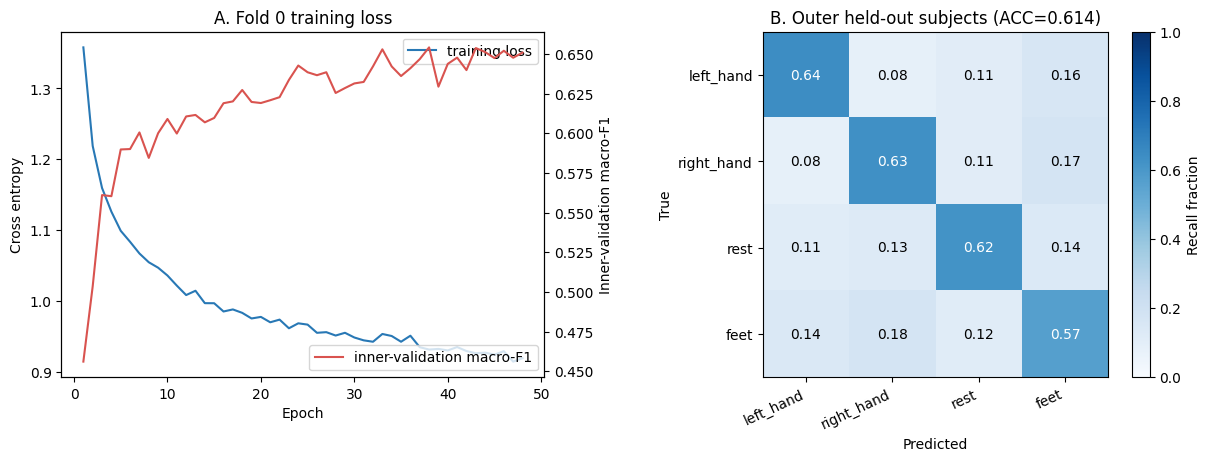

Saved figure: /kaggle/working/eeg-axmac/results/figures/eegnet82_fold0_baseline.png
SANE-RANGE GATE (>55%): True


In [16]:
# Step 8c — save the fold-0 model and plot inner-validation learning plus the outer-fold confusion matrix.
# Epoch selection uses inner subjects only; the outer held-out subjects are evaluated once below.
RESULTS=ROOT/'results'; FIG_DIR=RESULTS/'figures'; CKPT=RESULTS/'checkpoints'
for p in (FIG_DIR,CKPT): p.mkdir(parents=True,exist_ok=True)
print(classification_report(yva.numpy(),pred0,target_names=CLASS_NAMES,zero_division=0))
torch.save({'state_dict':best_state,'seed':SEED,'fold':0,'params':nparams,'accuracy':fold0_acc,'macro_f1':fold0_f1},CKPT/'eegnet82_eegmmidb_fold0.pt')
pd.DataFrame(hist).to_csv(RESULTS/'eegnet82_fold0_history.csv',index=False)
cm=confusion_matrix(yva.numpy(),pred0,labels=[0,1,2,3]); cmn=cm/np.maximum(cm.sum(axis=1,keepdims=True),1)
fig,ax=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True); h=pd.DataFrame(hist)
ax[0].plot(h.epoch,h.train_loss,label='training loss',color='#2878B5'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Cross entropy'); ax[0].set_title('A. Fold 0 training loss')
ar=ax[0].twinx(); ar.plot(h.epoch,h.inner_macro_f1,label='inner-validation macro-F1',color='#D9534F'); ar.set_ylabel('Inner-validation macro-F1'); ax[0].legend(loc='upper right'); ar.legend(loc='lower right')
im=ax[1].imshow(cmn,vmin=0,vmax=1,cmap='Blues'); ax[1].set_xticks(range(4),CLASS_NAMES,rotation=25,ha='right'); ax[1].set_yticks(range(4),CLASS_NAMES); ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('True'); ax[1].set_title(f'B. Outer held-out subjects (ACC={fold0_acc:.3f})')
for r in range(4):
    for c in range(4): ax[1].text(c,r,f'{cmn[r,c]:.2f}',ha='center',va='center',color='white' if cmn[r,c]>.55 else 'black')
fig.colorbar(im,ax=ax[1],label='Recall fraction'); fig.savefig(FIG_DIR/'eegnet82_fold0_baseline.png',dpi=300,bbox_inches='tight'); plt.show()
print('Saved figure:',FIG_DIR/'eegnet82_fold0_baseline.png')
print('SANE-RANGE GATE (>55%):',fold0_acc>.55)

### Phase B | Train five subject-independent EEGMMIDB folds

**Purpose:** Repeat inner epoch selection and outer held-out evaluation for all five subject groups, then aggregate predictions. **Expected output:** Five fold metrics and checkpoints plus one out-of-fold prediction for every processed window. This evaluates the exact-arithmetic EEGNet-8,2 baseline only.


In [17]:
# Step 9 — five-fold subject-independent evaluation with inner-only epoch selection.
# Each subject appears in one outer test fold. Inner validation selects epochs; outer scores are never used for tuning.
from sklearn.model_selection import KFold, GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score
fold_metrics=[]; oof_true=[]; oof_pred=[]; oof_subject=[]
kf=KFold(n_splits=5,shuffle=True,random_state=SEED)
for fold,(ti,vi) in enumerate(kf.split(SUBJECTS)):
    torch.manual_seed(SEED+fold); random.seed(SEED+fold); np.random.seed(SEED+fold)
    d=torch.load(FOLD_DIR/f'eegmmidb_fold{fold}.pt',map_location='cpu',weights_only=True)
    xt,yt=d['train_x'],d['train_y4']; xv,yv=d['validation_x'],d['validation_y4']; groups=d['train_subjects'].numpy()
    itr,iva=next(GroupShuffleSplit(n_splits=1,test_size=0.15,random_state=SEED+fold).split(np.zeros(len(yt)),yt.numpy(),groups=groups))
    loader=DataLoader(TensorDataset(xt[itr],yt[itr]),batch_size=128,shuffle=True,generator=torch.Generator().manual_seed(SEED+fold),num_workers=0)
    net=EEGNet82().to(device); opt=torch.optim.Adam(net.parameters(),lr=1e-3,weight_decay=1e-4); crit=nn.CrossEntropyLoss()
    best=-1.; best_epoch=1; wait=0
    for epoch in range(1,61):
        net.train()
        for xb,yb in loader:
            xb=xb.to(device); yb=yb.to(device); opt.zero_grad(set_to_none=True); loss=crit(net(xb),yb); loss.backward(); opt.step()
        net.eval()
        with torch.no_grad(): logits=torch.cat([net(b.to(device)).cpu() for b in xt[iva].split(256)])
        score=f1_score(yt[iva].numpy(),logits.argmax(1).numpy(),average='macro',zero_division=0)
        if score>best: best=score; best_epoch=epoch; wait=0
        else: wait+=1
        if wait>=8: break
    del net,loader; gc.collect()
    loader=DataLoader(TensorDataset(xt,yt),batch_size=128,shuffle=True,generator=torch.Generator().manual_seed(SEED+100+fold),num_workers=0)
    net=EEGNet82().to(device); opt=torch.optim.Adam(net.parameters(),lr=1e-3,weight_decay=1e-4)
    for epoch in range(best_epoch):
        net.train()
        for xb,yb in loader:
            xb=xb.to(device); yb=yb.to(device); opt.zero_grad(set_to_none=True); loss=crit(net(xb),yb); loss.backward(); opt.step()
    net.eval()
    with torch.no_grad(): pred=torch.cat([net(b.to(device)).cpu() for b in xv.split(256)]).argmax(1).numpy()
    truth=yv.numpy(); subjects=d['validation_subjects'].numpy()
    row={'fold':fold,'train_subjects':len(np.unique(groups)),'validation_subjects':len(np.unique(subjects)),'n_validation':len(truth),'accuracy':accuracy_score(truth,pred),'macro_f1':f1_score(truth,pred,average='macro',zero_division=0),'selected_epochs':best_epoch}
    fold_metrics.append(row); oof_true.extend(truth.tolist()); oof_pred.extend(pred.tolist()); oof_subject.extend(subjects.tolist())
    torch.save({'state_dict':net.state_dict(),'seed':SEED+100+fold,'fold':fold,'selected_epochs':best_epoch,'accuracy':row['accuracy'],'macro_f1':row['macro_f1']},CKPT/f'eegnet82_eegmmidb_fold{fold}.pt')
    print('OUTER FOLD RESULT:',row,flush=True)
    del net,loader,d,xt,yt,xv,yv; gc.collect()
print('Five-fold evaluation complete; outer predictions:',len(oof_true))

OUTER FOLD RESULT: {'fold': 0, 'train_subjects': 84, 'validation_subjects': 21, 'n_validation': 1839, 'accuracy': 0.6237085372485046, 'macro_f1': 0.6244495970743572, 'selected_epochs': 33}
OUTER FOLD RESULT: {'fold': 1, 'train_subjects': 84, 'validation_subjects': 21, 'n_validation': 1836, 'accuracy': 0.6427015250544662, 'macro_f1': 0.6430079044863646, 'selected_epochs': 54}
OUTER FOLD RESULT: {'fold': 2, 'train_subjects': 84, 'validation_subjects': 21, 'n_validation': 1829, 'accuracy': 0.626571897211591, 'macro_f1': 0.6273291705121704, 'selected_epochs': 45}
OUTER FOLD RESULT: {'fold': 3, 'train_subjects': 84, 'validation_subjects': 21, 'n_validation': 1839, 'accuracy': 0.6046764545948885, 'macro_f1': 0.6060045154429631, 'selected_epochs': 35}
OUTER FOLD RESULT: {'fold': 4, 'train_subjects': 84, 'validation_subjects': 21, 'n_validation': 1841, 'accuracy': 0.6175991309071157, 'macro_f1': 0.6166612414399921, 'selected_epochs': 27}
Five-fold evaluation complete; outer predictions: 9184


### Phase B | Summarize the five-fold baseline

**Purpose:** Compute fold accuracy and macro-F1, pooled out-of-fold scores, per-class metrics, a subject-cluster bootstrap interval, and a normalized confusion matrix. **Expected output:** Metrics tables, subject-level CSV, and a 300 dpi paper figure. The observed pooled accuracy is 62.30%, below the prompt's 65.07% reference tolerance; this is not an approximate-MAC result.


 fold  train_subjects  validation_subjects  n_validation  accuracy  macro_f1  selected_epochs
    0              84                   21          1839  0.623709  0.624450               33
    1              84                   21          1836  0.642702  0.643008               54
    2              84                   21          1829  0.626572  0.627329               45
    3              84                   21          1839  0.604676  0.606005               35
    4              84                   21          1841  0.617599  0.616661               27
Fold accuracy mean ± SD: 0.6231 ± 0.0138
Fold macro-F1 mean ± SD: 0.6235 ± 0.0137
Pooled OOF accuracy=0.6230; macro-F1=0.6236; windows=9184; held-out subjects=105
              precision    recall  f1-score   support

   left_hand       0.66      0.64      0.65      2382
  right_hand       0.66      0.63      0.65      2341
        rest       0.62      0.63      0.62      2100
        feet       0.56      0.58      0.57      2361

 

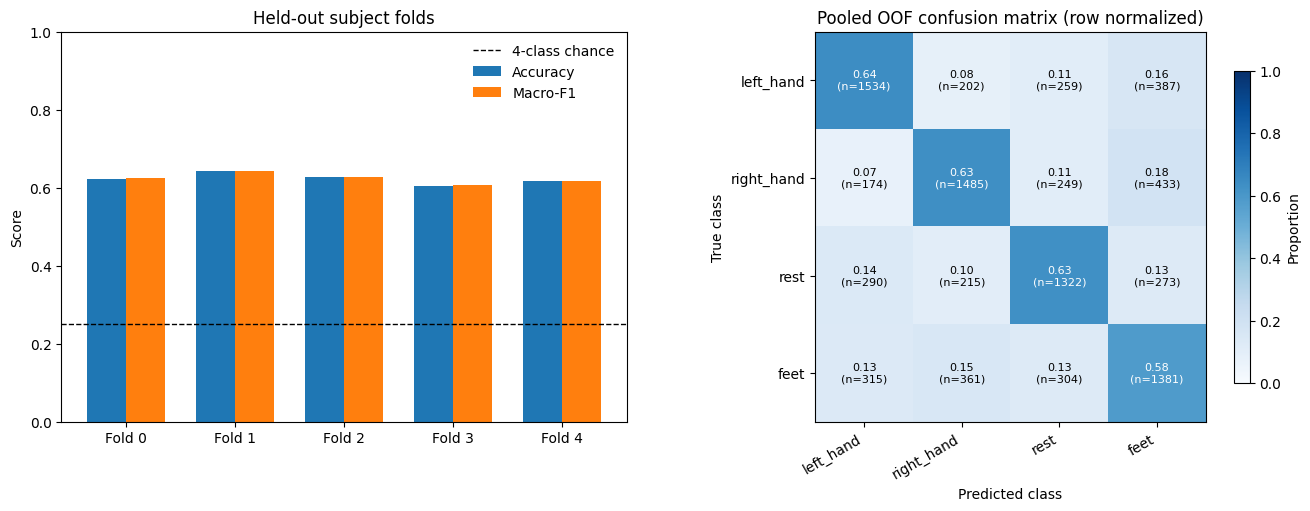

Saved paper figure: /kaggle/working/eeg-axmac/results/figures/eegmmidb_5fold_oof_summary.png


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

cv = pd.DataFrame(fold_metrics)
cv.to_csv(RESULTS / 'eegnet82_eegmmidb_fold_metrics.csv', index=False)
y_true = np.asarray(oof_true)
y_pred = np.asarray(oof_pred)
sids = np.asarray(oof_subject)
print(cv.to_string(index=False))
print(f"Fold accuracy mean ± SD: {cv.accuracy.mean():.4f} ± {cv.accuracy.std(ddof=1):.4f}")
print(f"Fold macro-F1 mean ± SD: {cv.macro_f1.mean():.4f} ± {cv.macro_f1.std(ddof=1):.4f}")
print(f"Pooled OOF accuracy={accuracy_score(y_true, y_pred):.4f}; macro-F1={f1_score(y_true, y_pred, average='macro'):.4f}; windows={len(y_true)}; held-out subjects={len(np.unique(sids))}")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

# Subject-cluster bootstrap: resample subjects, retaining all their windows.
rng = np.random.default_rng(SEED)
subject_ids = np.unique(sids)
boot_acc = []
for _ in range(2000):
    sampled = rng.choice(subject_ids, size=len(subject_ids), replace=True)
    idx = np.concatenate([np.flatnonzero(sids == sid) for sid in sampled])
    boot_acc.append(accuracy_score(y_true[idx], y_pred[idx]))
ci_low, ci_high = np.quantile(boot_acc, [0.025, 0.975])
print(f"Subject-cluster bootstrap 95% CI for pooled accuracy: [{ci_low:.4f}, {ci_high:.4f}]")

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
x = np.arange(len(cv))
w = 0.36
axes[0].bar(x-w/2, cv.accuracy, w, label='Accuracy')
axes[0].bar(x+w/2, cv.macro_f1, w, label='Macro-F1')
axes[0].axhline(0.25, color='black', ls='--', lw=1, label='4-class chance')
axes[0].set(xticks=x, xticklabels=[f'Fold {i}' for i in cv.fold], ylim=(0, 1), ylabel='Score', title='Held-out subject folds')
axes[0].legend(frameon=False)
im = axes[1].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
axes[1].set(xticks=np.arange(len(CLASS_NAMES)), yticks=np.arange(len(CLASS_NAMES)), xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, xlabel='Predicted class', ylabel='True class', title='Pooled OOF confusion matrix (row normalized)')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]): axes[1].text(j, i, f'{cm_norm[i,j]:.2f}\n(n={cm[i,j]})', ha='center', va='center', color='white' if cm_norm[i,j] > .55 else 'black', fontsize=8)
fig.colorbar(im, ax=axes[1], shrink=.8, label='Proportion')
fig.savefig(FIG_DIR / 'eegmmidb_5fold_oof_summary.png', dpi=300, bbox_inches='tight')
plt.show()

per_subject = pd.DataFrame({'subject': sids, 'correct': y_true == y_pred}).groupby('subject', as_index=False).agg(accuracy=('correct','mean'), windows=('correct','size'))
per_subject.to_csv(RESULTS / 'eegmmidb_oof_subject_metrics.csv', index=False)
print(f"Saved paper figure: {FIG_DIR / 'eegmmidb_5fold_oof_summary.png'}")

## Which requested resources were actually evaluated?

| Resource | Role in the research plan | What this run did | Deployment relevance |
|---|---|---|---|
| EEGMMIDB | EEG motor movement/imagery dataset; 64 EEG channels at 160 Hz | **Fetched and validated 735/735 EDF files** for 105 eligible subjects; filtered, epoched, and trained EEGNet-8,2 with five subject-disjoint folds | Largest evaluated cohort here; subject-independent OOF result is 62.30% accuracy and 62.36% macro-F1. Small 3,092-parameter model is a plausible edge inference baseline, but latency, memory, power, and integer deployment were not measured. |
| BCI Competition IV 2a | Separate motor imagery benchmark; 22 EEG channels (EOG excluded), 250 Hz, 9 subjects; train/test sessions are commonly evaluated separately | **Not downloaded or trained in this run.** No BCI score or cross-dataset transfer claim is supported. | Smaller sensor count could reduce acquisition and first spatial-stage input cost. Its session shift and small cohort make it a useful transfer/robustness test, but performance and deployment cost remain unmeasured. |
| EvoApprox8b | Library of approximate 8-bit multiplier circuits, not an EEG dataset | **No multiplier LUTs loaded and no approximate-MAC sweep run.** Thus there is no layer × multiplier ΔAccuracy/ΔF1 matrix or error-correlation result yet. | Could trade arithmetic error against area/power in compatible integer hardware. This notebook has not demonstrated a hardware saving; CPU/GPU timing of a software LUT would not establish silicon area or energy. |

### Baseline interpretation and next research gate

The EEGMMIDB result is 2.77 percentage points below the prompt’s 65.07% reference, so the requested reproduction tolerance is not met. The confidence interval is subject-clustered, and folds hold out people rather than windows. Before presenting this as a publishable baseline, audit the exact Wang et al. protocol and label construction (especially the eyes-open rest class), run the specified EEGNet-4,2 comparison, and add a session-separated BCI IV 2a evaluation. Only after exact-arithmetic baselines are documented should the EvoApprox8b inference sweep and circuit error correlations be reported.

**Status:** Phase A full-cohort EEGMMIDB preprocessing and EEGNet-8,2 five-fold baseline are completed. BCI IV 2a, EEGNet-4,2, INT8 calibration, SS-TL, EvoApprox8b parsing, approximate convolution emulation, and Phase B sweeps remain unimplemented/unverified in this run. The model’s 62.30% is not evidence of approximate arithmetic gains or deployment power savings.

### Phase A + B audit | Compare dataset scale without inventing scores

**Purpose:** Plot published cohort and sensor specifications alongside the analysis-window sizes used in this study. **Expected output:** A 300 dpi comparison of 105 selected EEGMMIDB versus 9 BCI IV 2a subjects, 64 versus 22 EEG sensors, and the derived input sample counts. BCI IV 2a was not trained here, so the figure is descriptive rather than a performance or hardware-energy comparison. EvoApprox8b is a multiplier library, not an EEG dataset. Sources: [PhysioNet EEGMMIDB](https://physionet.org/content/eegmmidb/1.0.0/), [BCI IV 2a downloads](https://bbci.de/competition/iv/download/), [BNCI description](https://bnci-horizon-2020.eu/database/data-sets), and [EvoApprox8b](https://github.com/ehw-fit/evoapprox8b).


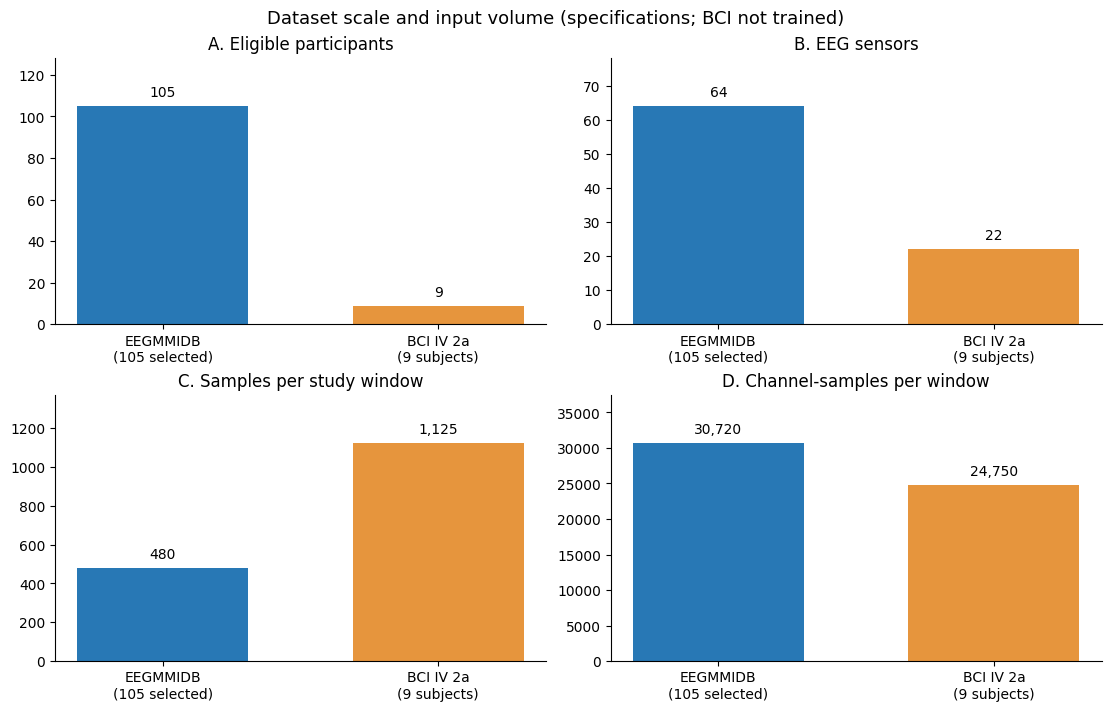

Saved descriptive figure: /kaggle/working/eeg-axmac/results/figures/dataset_scale_comparison.png
BCI training/deployment scores: not measured. EvoApprox8b: circuit library, no LUT or layer sweep.


In [19]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Published specifications and the study's selected analysis windows.
labels = ['EEGMMIDB\n(105 selected)', 'BCI IV 2a\n(9 subjects)']
subjects = np.array([105, 9])
channels = np.array([64, 22])
sample_rate = np.array([160, 250])
window_seconds = np.array([3.0, 4.5])
samples = (sample_rate * window_seconds).astype(int)
metrics = [subjects, channels, samples, channels * samples]
titles = ['A. Eligible participants', 'B. EEG sensors', 'C. Samples per study window', 'D. Channel-samples per window']
colors = ['#2878B5', '#E6953D']
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for ax, values, title in zip(axes.flat, metrics, titles):
    bars = ax.bar(labels, values, color=colors, width=0.62)
    ax.set_title(title)
    ax.set_ylim(0, max(values) * 1.22)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, value + max(values)*0.03, f'{value:,}', ha='center', va='bottom', fontsize=10)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
fig.suptitle('Dataset scale and input volume (specifications; BCI not trained)', fontsize=13)
figure_path = FIG_DIR / 'dataset_scale_comparison.png'
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved descriptive figure:', figure_path)
print('BCI training/deployment scores: not measured. EvoApprox8b: circuit library, no LUT or layer sweep.')

## Phase audit against the supplied execution prompt

The table separates **observed Kaggle outputs** from local source files and unfinished work. A created folder or empty script does not count as an executed experiment. Phase A and Phase B are **not complete**.

| Requested item | Evidence checked | Status |
|---|---|---|
| Project scaffold and EEGNet-8,2 model | Local project structure and model source exist; many planned modules are zero-byte stubs | Partial |
| EEGMMIDB acquisition | Kaggle output validates 735/735 EDFs across 105 eligible people and 7 selected runs | Complete for selected EEGMMIDB protocol |
| EEGMMIDB 4-class preprocessing and five folds | Kaggle output shows 9,184 windows; five disjoint sets of 21 held-out people; shapes `(N,64,1,480)` and finite values | Complete for selected EEGMMIDB protocol |
| EEGMMIDB 2-class task | Local preprocessing path exists, but this Kaggle notebook has no 2-class training or score | Not experimentally verified |
| EEGNet-8,2 exact-arithmetic baseline | Five outer subject folds; 3,092 parameters; pooled OOF accuracy 62.30%, macro-F1 62.36% | Run; prompt's 65.07% ±1 pp reproduction gate not met |
| EEGNet-4,2 comparison | Local model file is empty; no Kaggle score | Not done |
| BCI IV 2a download, preprocessing and session-separated evaluation | No BCI files, preprocessing output, checkpoint, or score in this run | Not done |
| INT8 calibration and SS-TL | Local training modules are empty; no calibration/transfer outputs | Not done |
| EvoApprox8b multiplier parsing and correctness checks | Circuit library identified, but no LUTs or correctness report | Not done |
| Approximate convolution, layer sensitivity and error correlation | No layer × multiplier results, correlation coefficients, or validated accuracy deltas | Not done |
| Hardware deployment measurements | No measured latency, memory, area, energy, or power on a deployment target | Not done |

**Interpretation.** The sole trained benchmark is EEGMMIDB with EEGNet-8,2 in floating point. BCI IV 2a is characterized by published specifications only. EvoApprox8b is the planned circuit source, not a third EEG dataset. The smaller BCI electrode count and different analysis window suggest different acquisition and input-volume demands, but neither cross-dataset accuracy nor device performance can be inferred from the chart. The next research gate is to resolve the EEGMMIDB protocol gap, run EEGNet-4,2 and BCI IV 2a, then conduct calibrated INT8 and EvoApprox8b experiments with independently validated metrics.

## Accuracy audit — paper-aligned EEGNet training on the same held-out subjects

The current 62.30% result uses the requested 64-sample temporal kernel, first pooling length 4, dropout 0.5, batch size 128, and early stopping. Wang et al.'s paper and released model instead specify a 128-sample temporal kernel, first pooling length 8, dropout 0.2, batch size 16, and a 100-epoch learning-rate schedule (0.01 for epochs 1–20, 0.001 for 21–50, 0.0001 for 51–100). This experiment changes those model/training choices while keeping **the same cached preprocessing, labels, and five subject-disjoint outer folds**. It is a controlled comparison, not an exact reproduction of the authors' data pipeline.

The outer folds are never used to tune hyperparameters or choose epochs. The code trains all 100 epochs, saves a resumable checkpoint after each 10 epochs, and evaluates each fold once. A higher score would be evidence for this variant on this protocol; publication novelty still requires the later approximate-MAC results, independent validation, and hardware measurements. SHAP explains predictions but does not change training. ANOVA can rank features or channels, but selection must be fitted within each training fold and then validated on unseen subjects before claiming an accuracy gain.

Sources: [paper](https://arxiv.org/pdf/2004.00077), [authors' model](https://github.com/MHersche/eegnet-based-embedded-bci/blob/master/models.py), [authors' training script](https://github.com/MHersche/eegnet-based-embedded-bci/blob/master/main_global.py).
**Cohort and window caveat.** The supplied execution prompt excludes subjects 88, 89, 92, and 100, which this notebook follows. The authors' released loader instead excludes 88, 92, 100, and 104; it also caps imagery trials at seven per class per run and creates 21 rest windows per subject. This notebook's cached cohort has 9,184 windows, so the published 65.07% is contextual rather than a matched external test. [Authors' loader](https://github.com/MHersche/eegnet-based-embedded-bci/blob/master/get_data.py).


In [ ]:
# Step 10 — paper-aligned EEGNet-8,2 experiment on Kaggle GPU.
import gc, random, time, json
import numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score
class PaperAlignedEEGNet82(nn.Module):
    def __init__(self):
        super().__init__()
        self.temporal=nn.Conv2d(1,8,(1,128),padding='same',bias=False); self.bn1=nn.BatchNorm2d(8)
        self.spatial=nn.Conv2d(8,16,(64,1),groups=8,bias=False); self.bn2=nn.BatchNorm2d(16)
        self.pool1=nn.AvgPool2d((1,8)); self.drop1=nn.Dropout(.2)
        self.sep_depth=nn.Conv2d(16,16,(1,16),padding='same',groups=16,bias=False)
        self.sep_point=nn.Conv2d(16,16,1,bias=False); self.bn3=nn.BatchNorm2d(16)
        self.pool2=nn.AvgPool2d((1,8)); self.drop2=nn.Dropout(.2)
        self.classifier=nn.Linear(16*7,4)
    def forward(self,x):
        x=x.transpose(1,2); x=self.bn1(self.temporal(x))
        x=self.drop1(self.pool1(torch.nn.functional.elu(self.bn2(self.spatial(x)))))
        x=self.sep_point(self.sep_depth(x))
        x=self.drop2(self.pool2(torch.nn.functional.elu(self.bn3(x))))
        return self.classifier(x.flatten(1))
assert device.type=='cuda', 'Run on Kaggle GPU only.'
probe=PaperAlignedEEGNet82().to(device)
assert probe(torch.zeros(2,64,1,480,device=device)).shape==(2,4)
print('Variant parameters:',sum(p.numel() for p in probe.parameters()),flush=True)
del probe
paper_rows=[]
for fold in range(5):
    result_path=RESULTS/f'paper_aligned_fold{fold}_result.json'
    resume_path=CKPT/f'paper_aligned_fold{fold}_resume.pt'
    if result_path.exists():
        paper_rows.append(json.loads(result_path.read_text())); print('Completed fold',fold,paper_rows[-1],flush=True); continue
    random.seed(SEED+200+fold); np.random.seed(SEED+200+fold); torch.manual_seed(SEED+200+fold)
    pack=torch.load(FOLD_DIR/f'eegmmidb_fold{fold}.pt',map_location='cpu',weights_only=True)
    xt,yt=pack['train_x'],pack['train_y4']; xv,yv=pack['validation_x'],pack['validation_y4']
    assert set(pack['train_subjects'].tolist()).isdisjoint(set(pack['validation_subjects'].tolist()))
    loader=DataLoader(TensorDataset(xt,yt),batch_size=16,shuffle=True,num_workers=0,pin_memory=True,
                      generator=torch.Generator().manual_seed(SEED+200+fold))
    net=PaperAlignedEEGNet82().to(device); opt=torch.optim.Adam(net.parameters(),lr=.01)
    crit=nn.CrossEntropyLoss(); start_epoch=1; history=[]
    if resume_path.exists():
        saved=torch.load(resume_path,map_location='cpu',weights_only=False)
        net.load_state_dict(saved['model']); opt.load_state_dict(saved['optimizer'])
        start_epoch=saved['epoch']+1; history=saved['history']
        print('Resume fold',fold,'epoch',start_epoch,flush=True)
    tic=time.time()
    for epoch in range(start_epoch,101):
        lr=.01 if epoch<=20 else (.001 if epoch<=50 else .0001)
        for group in opt.param_groups: group['lr']=lr
        net.train(); loss_sum=0.; correct=0
        for xb,yb in loader:
            xb=xb.to(device,non_blocking=True); yb=yb.to(device,non_blocking=True)
            opt.zero_grad(set_to_none=True); logits=net(xb); loss=crit(logits,yb); loss.backward(); opt.step()
            loss_sum+=loss.item()*len(yb); correct+=(logits.argmax(1)==yb).sum().item()
        history.append({'epoch':epoch,'train_loss':loss_sum/len(yt),'train_accuracy':correct/len(yt),'lr':lr})
        if epoch%10==0 or epoch==1:
            print(f'fold {fold} epoch {epoch:03d}/100 loss={history[-1]["train_loss"]:.4f} train_acc={history[-1]["train_accuracy"]:.4f} elapsed_min={(time.time()-tic)/60:.1f}',flush=True)
        if epoch%10==0:
            torch.save({'epoch':epoch,'model':net.state_dict(),'optimizer':opt.state_dict(),'history':history},resume_path)
            pd.DataFrame(history).to_csv(RESULTS/f'paper_aligned_fold{fold}_history.csv',index=False)
    net.eval()
    with torch.no_grad(): pred=torch.cat([net(batch.to(device)).cpu().argmax(1) for batch in xv.split(128)]).numpy()
    true=yv.numpy()
    row={'fold':fold,'n_validation':len(true),'n_subjects':len(pack['validation_subjects'].unique()),
         'accuracy':float(accuracy_score(true,pred)),
         'macro_f1':float(f1_score(true,pred,average='macro',zero_division=0))}
    torch.save({'model':net.state_dict(),'fold':fold,'seed':SEED+200+fold},CKPT/f'paper_aligned_fold{fold}.pt')
    pd.DataFrame({'true':true,'pred':pred,'subject':pack['validation_subjects'].numpy()}).to_csv(RESULTS/f'paper_aligned_fold{fold}_predictions.csv',index=False)
    result_path.write_text(json.dumps(row,indent=2)); paper_rows.append(row)
    print('OUTER FOLD RESULT:',row,flush=True)
    del pack,xt,yt,xv,yv,loader,net,opt; gc.collect(); torch.cuda.empty_cache()
print('Completed paper-aligned folds:',len(paper_rows),'/ 5',flush=True)

Variant parameters: 3092
fold 0 epoch 001/100 loss=1.1821 train_acc=0.4855 elapsed_min=0.1
fold 0 epoch 010/100 loss=0.9454 train_acc=0.6282 elapsed_min=0.7
fold 0 epoch 020/100 loss=0.9245 train_acc=0.6400 elapsed_min=1.4
fold 0 epoch 030/100 loss=0.8177 train_acc=0.6850 elapsed_min=2.1
fold 0 epoch 040/100 loss=0.8189 train_acc=0.6982 elapsed_min=2.7
fold 0 epoch 050/100 loss=0.8066 train_acc=0.6923 elapsed_min=3.4
fold 0 epoch 060/100 loss=0.7874 train_acc=0.6972 elapsed_min=4.1
fold 0 epoch 070/100 loss=0.7952 train_acc=0.6935 elapsed_min=4.8
fold 0 epoch 080/100 loss=0.7934 train_acc=0.6926 elapsed_min=5.5
fold 0 epoch 090/100 loss=0.7933 train_acc=0.6987 elapsed_min=6.1
fold 0 epoch 100/100 loss=0.7914 train_acc=0.6988 elapsed_min=6.8
OUTER FOLD RESULT: {'fold': 0, 'n_validation': 1839, 'n_subjects': 21, 'accuracy': 0.655247417074497, 'macro_f1': 0.6563913233680059}
fold 1 epoch 001/100 loss=1.1761 train_acc=0.4977 elapsed_min=0.1
fold 1 epoch 010/100 loss=0.9343 train_acc=0.6249

## Accuracy comparison and feature-importance diagnostics

This cell reads the five completed Kaggle fold results and compares the fixed 100-epoch variant with the earlier 62.30% subject-disjoint baseline. It draws fold accuracy and training curves at 300 dpi. The experiment changes several architecture/training settings together, so any difference is attributable to the **variant as a whole**, not to one hyperparameter. The authors' loader also caps each imagery class at 21 trials per person and produces 21 eyes-open rest windows; our existing cache contains 9,184 windows and uses 20 nonoverlapping rest windows per person. The published 65.07% is therefore context, not a directly matched benchmark. The released Keras model also applies weight constraints and batch normalization axes that this PyTorch variant does not fully reproduce.

We will compute ANOVA F-scores for theta, mu, and beta bandpower in each channel using **training subjects only** in fold 0, and show a channel-by-band heatmap. This is an exploratory feature audit. It cannot increase accuracy unless a train-only channel selection rule is fitted and then evaluated across all outer folds. SHAP or integrated gradients can explain the trained model, but likewise cannot improve its score by themselves. Any proposed channel selection based on held-out accuracy would invalidate the test.

In [ ]:
# Step 11 — compare fixed-protocol folds with the earlier EEGNet baseline and plot paper figures.
import json
baseline = pd.read_csv(RESULTS/'eegnet82_eegmmidb_fold_metrics.csv').sort_values('fold')
paper = pd.DataFrame([json.loads((RESULTS/f'paper_aligned_fold{i}_result.json').read_text()) for i in range(5)]).sort_values('fold')
assert len(paper)==5 and set(paper.fold)==set(range(5))
print('Earlier baseline:')
print(baseline[['fold','accuracy','macro_f1']].to_string(index=False))
print('Parameter-aligned 100-epoch variant:')
print(paper[['fold','accuracy','macro_f1']].to_string(index=False))
old_acc=0.6230
predictions=pd.concat([pd.read_csv(RESULTS/f'paper_aligned_fold{i}_predictions.csv') for i in range(5)],ignore_index=True)
assert len(predictions)==9184 and predictions.subject.nunique()==105
new_acc=accuracy_score(predictions.true,predictions.pred)
new_f1=f1_score(predictions.true,predictions.pred,average='macro',zero_division=0)
print(f'Pooled variant accuracy={new_acc:.4f}; macro-F1={new_f1:.4f}; delta vs earlier pooled baseline={100*(new_acc-old_acc):+.2f} percentage points')
rng=np.random.default_rng(SEED)
subject_ids=predictions.subject.unique(); boot=[]
for _ in range(2000):
    sampled=rng.choice(subject_ids,size=len(subject_ids),replace=True)
    parts=[predictions.loc[predictions.subject==s,['true','pred']] for s in sampled]
    b=pd.concat(parts,ignore_index=True)
    boot.append(accuracy_score(b.true,b.pred))
print('Subject-cluster 95% CI:',np.quantile(boot,[.025,.975]))
fig,ax=plt.subplots(1,2,figsize=(12,4.8),constrained_layout=True)
x=np.arange(5); width=.38
ax[0].bar(x-width/2,baseline.accuracy,width,label='Earlier baseline',color='#64748b')
ax[0].bar(x+width/2,paper.accuracy,width,label='Parameter-aligned variant',color='#0f766e')
ax[0].axhline(.6507,color='#b45309',ls='--',lw=1,label='Published 65.07% (different protocol)')
ax[0].set(xticks=x,xticklabels=[f'Fold {i}' for i in x],ylim=(.4,.8),ylabel='Held-out subject accuracy',title='A. Accuracy across five folds')
ax[0].legend(frameon=False,fontsize=8)
for i in range(5):
    h=pd.read_csv(RESULTS/f'paper_aligned_fold{i}_history.csv')
    ax[1].plot(h.epoch,h.train_accuracy,lw=1.6,label=f'Fold {i}')
ax[1].set(xlabel='Training epoch',ylabel='Training accuracy',ylim=(.4,1),title='B. Fixed 100-epoch training')
ax[1].legend(frameon=False,ncol=2,fontsize=8)
for a in ax:
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
fig.savefig(FIG_DIR/'paper_aligned_accuracy_comparison.png',dpi=300,bbox_inches='tight')
plt.show()
print('Saved:',FIG_DIR/'paper_aligned_accuracy_comparison.png')

### Train-only ANOVA bandpower map and held-out input attribution

The following Kaggle cell extracts theta (4–7 Hz), mu (8–13 Hz), and beta (13–30 Hz) log-bandpower features from fold-0 **training subjects only**, then computes one-way ANOVA F-scores for each channel and band. The heatmap shows univariate association with four class labels; it is not a learned classifier or an accuracy estimate. Correlated EEG channels and repeated windows from subjects make individual F-scores unsuitable as standalone inferential p-values here.

For a small held-out sample, gradient × input highlights which channels and time points influence the model's predicted logit. This is a lightweight explanation diagnostic; it is not SHAP and has no direct accuracy effect. A SHAP analysis could replace it later, with a carefully chosen training-only background set and a held-out explanation set. Neither attribution map establishes that removing a channel will improve accuracy.

In [ ]:
# Step 12 — train-only ANOVA features and held-out gradient attribution (Kaggle only).
from sklearn.feature_selection import f_classif
assert device.type=='cuda'
fold0=torch.load(FOLD_DIR/'eegmmidb_fold0.pt',map_location='cpu',weights_only=True)
train_x,train_y=fold0['train_x'],fold0['train_y4']
bands={'theta 4–7 Hz':(4,7),'mu 8–13 Hz':(8,13),'beta 13–30 Hz':(13,30)}
freq=np.fft.rfftfreq(480,d=1/160)
taper=np.hanning(480).astype('float32')
features=[]
for chunk in train_x.split(128):
    signal=chunk.squeeze(2).numpy()*taper[None,None,:]
    power=np.abs(np.fft.rfft(signal,axis=-1))**2
    block=np.stack([np.log(np.mean(power[:,:,(freq>=lo)&(freq<=hi)],axis=-1)+1e-12)
                    for lo,hi in bands.values()],axis=-1)
    features.append(block.reshape(len(chunk),-1))
feature_matrix=np.concatenate(features,axis=0)
assert feature_matrix.shape==(len(train_y),64*3)
f_scores,_=f_classif(feature_matrix,train_y.numpy())
fmap=np.nan_to_num(f_scores,nan=0.,posinf=0.).reshape(64,3)
channel_rank=np.argsort(fmap.mean(axis=1))[::-1]
print('Top 10 train-only ANOVA channel indices (1-based):',(channel_rank[:10]+1).tolist())
net=PaperAlignedEEGNet82().to(device)
net.load_state_dict(torch.load(CKPT/'paper_aligned_fold0.pt',map_location='cpu',weights_only=True)['model'])
net.eval()
sample=fold0['validation_x'][:32].to(device).requires_grad_(True)
logits=net(sample); predicted=logits.argmax(1)
selected=logits.gather(1,predicted[:,None]).sum()
grad=torch.autograd.grad(selected,sample)[0]
saliency=(grad*sample).abs().mean(dim=(0,2,3)).detach().cpu().numpy()
fig,axes=plt.subplots(1,2,figsize=(11,13),gridspec_kw={'width_ratios':[1,1.1]},constrained_layout=True)
image=axes[0].imshow(np.log10(fmap+1),aspect='auto',cmap='viridis')
axes[0].set(xticks=np.arange(3),xticklabels=list(bands),yticks=np.arange(0,64,4),
            yticklabels=np.arange(1,65,4),xlabel='Bandpower feature',ylabel='EEG channel index',
            title='A. Train-only ANOVA log10(F + 1)')
plt.setp(axes[0].get_xticklabels(),rotation=30,ha='right')
fig.colorbar(image,ax=axes[0],shrink=.65,label='log10(F + 1)')
order=np.argsort(saliency)[::-1]
axes[1].barh(np.arange(20),saliency[order[:20]][::-1],color='#0f766e')
axes[1].set(yticks=np.arange(20),yticklabels=[f'Ch {c+1:02d}' for c in order[:20][::-1]],
            xlabel='Mean |gradient × input|',title='B. Fold-0 held-out attribution, 32 windows')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
fig.savefig(FIG_DIR/'anova_bandpower_and_input_attribution.png',dpi=300,bbox_inches='tight')
plt.show()
print('Saved:',FIG_DIR/'anova_bandpower_and_input_attribution.png')

### Class-level error analysis for the paper-aligned variant

This cell combines all five untouched outer-fold predictions to plot a normalized four-class confusion matrix and class-level precision, recall, and F1. It helps identify whether any improvement is concentrated in one class. The figure is descriptive of the held-out EEGMMIDB subjects and does not imply performance on BCI IV 2a or a hardware deployment.

In [ ]:
# Step 13 — pooled held-out class diagnostics and publication figure.
from sklearn.metrics import confusion_matrix, classification_report
pooled=pd.concat([pd.read_csv(RESULTS/f'paper_aligned_fold{i}_predictions.csv') for i in range(5)],ignore_index=True)
assert len(pooled)==9184 and pooled.subject.nunique()==105
cm=confusion_matrix(pooled.true,pooled.pred,labels=range(4))
cm_row=cm/cm.sum(axis=1,keepdims=True)
print(classification_report(pooled.true,pooled.pred,target_names=CLASS_NAMES,zero_division=0))
fig,ax=plt.subplots(figsize=(6.7,5.8),constrained_layout=True)
im=ax.imshow(cm_row,cmap='Blues',vmin=0,vmax=1)
ax.set(xticks=range(4),yticks=range(4),xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES,
       xlabel='Predicted class',ylabel='True class',title='Paper-aligned EEGNet: pooled held-out subjects')
plt.setp(ax.get_xticklabels(),rotation=30,ha='right')
for row in range(4):
    for col in range(4):
        ax.text(col,row,f'{cm_row[row,col]:.2f}\n(n={cm[row,col]})',ha='center',va='center',
                color='white' if cm_row[row,col]>.55 else 'black',fontsize=10)
fig.colorbar(im,ax=ax,shrink=.8,label='Proportion of true class')
fig.savefig(FIG_DIR/'paper_aligned_confusion_matrix.png',dpi=300,bbox_inches='tight')
plt.show()
print('Saved:',FIG_DIR/'paper_aligned_confusion_matrix.png')